<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex6_Policy_Learning/TNSII_Ex6_policy_learning_solved_k7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Policy learning

When animals and humans experience rewards or punishments (conditioning), they learn
to modify their behaviour accordingly.
To illustrate this ‘policy learning’, we consider bees learning to forage efficiently for nectar
from flowers. After visiting different flowers, bees typically return to the most rewarding
flower. When rewards (nectar amount) change, bees learn to change their preference.
This exercise implements both ‘indirect’ and ‘direct’ actor schemes for policy learning.

## Foraging among yellow and blue flowers


Assume that bees visit blue or yellow flowers with probabilities $P_b$ and $P_y$, respectively, which are determined by `action values', $m_b$ and $m_y$,

$$
P_b = \frac{1}{1+\exp\left[\beta\, (\bar m - m_b) \right]},
\qquad\qquad
P_y = \frac{1}{1+\exp\left[\beta\, (\bar m - m_y) \right]},
\qquad\qquad
P_b+P_y=1
$$

where $\bar m = \frac{1}{2} (m_b + m_y)$ is the average action value and $\beta$ is a constant determining the variability or consistency of the bee's choices.  A small $\beta$ favours random choices (*exploration*) and large $\beta$ favours deterministic choices (*exploitation*).

You will simulate two foraging periods with random (Gaussian distributed) rewards.  A first period with rewards favouring 'blue'

\\

$$
\langle r_b \rangle = \mathrm{normrnd}(3,1),\qquad\qquad r_y=\mathrm{normrnd}(1,1)
$$

\\

is followed by a second period with rewards favoring 'yellow':

\\

$$
\langle r_b \rangle  = \mathrm{normrnd}(1,1),\qquad\qquad r_y=\mathrm{normrnd}(3,1)
$$

## Indirect actor

Simulate a bee learning from experience with an 'indirect actor' rule (Rescorla-Wagner rule)!   Note that 'indirect actor' are sort of intellectual in that their actions are based on 'world model' (expected nectar yield of blue and yellow flowers, $m_b$ and $m_y$).


Starting from $m_b=m_y=0$, have your bee visit flowers with probabilities $P_b(m_b,m_y)$ and $P_y(m_b,m_y)$ and provide with a random reward (as described above)!  After each visit, adjust the action values as follows:


**Visit blue:**
$$
m_b \to m_b + \epsilon \, \delta_b, \qquad\qquad \delta_b = r_b - m_b
\\
m_y \to m_y  \quad\qquad\qquad \quad\qquad
$$


**Visit yellow:**
$$
m_b \to m_b  \quad\qquad\qquad \quad\qquad
\\
m_y \to m_y + \epsilon \, \delta_y, \qquad\qquad \delta_y = r_y - m_y
$$

where $\epsilon$ is a learning rate.


Simulate a sufficient number $N$ of visits in each of the two phases, so that the action values approach the expected rewards
$$
m_y \to \langle r_y \rangle, \qquad\qquad m_b \to \langle r_b \rangle
$$


Plot the development over $2N$ trials of action values $m_b$, $m_y$, visit probabilities $P_b$, $P_y$, instantaneous rewards $r_b$ or $r_y$, and cumulative rewards $\sum \, r_b$ and $\sum \, r_y$!


## Direct actor


Simulate another bee learning with a 'direct actor' rule!  Note that `direct actors' are sort of pragmatical in that they seek to maximize total expected reward $ \langle r \rangle = P_b \, \langle r_b\rangle + P_y \,  \langle r_y \rangle$, without troubling to learn the reward of individual flowers ($ \langle r_b \rangle$ and $\langle r_y \rangle$).


Starting from $m_b=m_y=0$, have your bee visit flowers with probabilities $P_b(m_b,m_y)$ and $P_y(m_b,m_y)$ and provide with a random reward (as described above)!  After each visit, adjust the action values as follows:


**Visit blue:**
$$
m_b \quad\to\quad m_b + \epsilon \, (1-P_b) \, \delta, \qquad\qquad \delta = r_b - \bar r
\\
m_y \quad\to\quad m_y - \epsilon \, P_y \, \delta \qquad\quad\qquad\qquad\qquad\qquad
$$


**Visit yellow:**
$$
m_b \quad\to\quad m_b - \epsilon \, P_b \, \delta, \qquad\qquad\qquad \delta = r_y - \bar r
\\
m_y \quad\to\quad m_y + \epsilon \, (1-P_r) \, \delta \qquad\quad\qquad\qquad\qquad
$$

\\

where $\epsilon$ is a learning rate and $\bar r$ is the mean reward under the current policy.  A reasonable estimate of $\bar r$ is the mean reward received over the last $n=10$ trials.


Simulate a sufficient number $N$ of visits in each of the two phases, so that the action probabilities come to reflect the current reward differences!


Plot the development over $2N$ trials of action values $m_b$, $m_y$, visit probabilities $P_b$, $P_y$, instantaneous rewards $r_b$ or $r_y$, and cumulative rewards $\sum \, r_b$ and $\sum \, r_y$!


## Comparison

Compare the indirect and direct learning approaches! How does cumulative reward (overall success)  depend on the exploration-exploitation balance $\beta$ and the learning rate $\epsilon$?   How do instantaneous rewards affect action values?  How quickly does your bee learn?  How quickly does it adjust to changed circumstances?





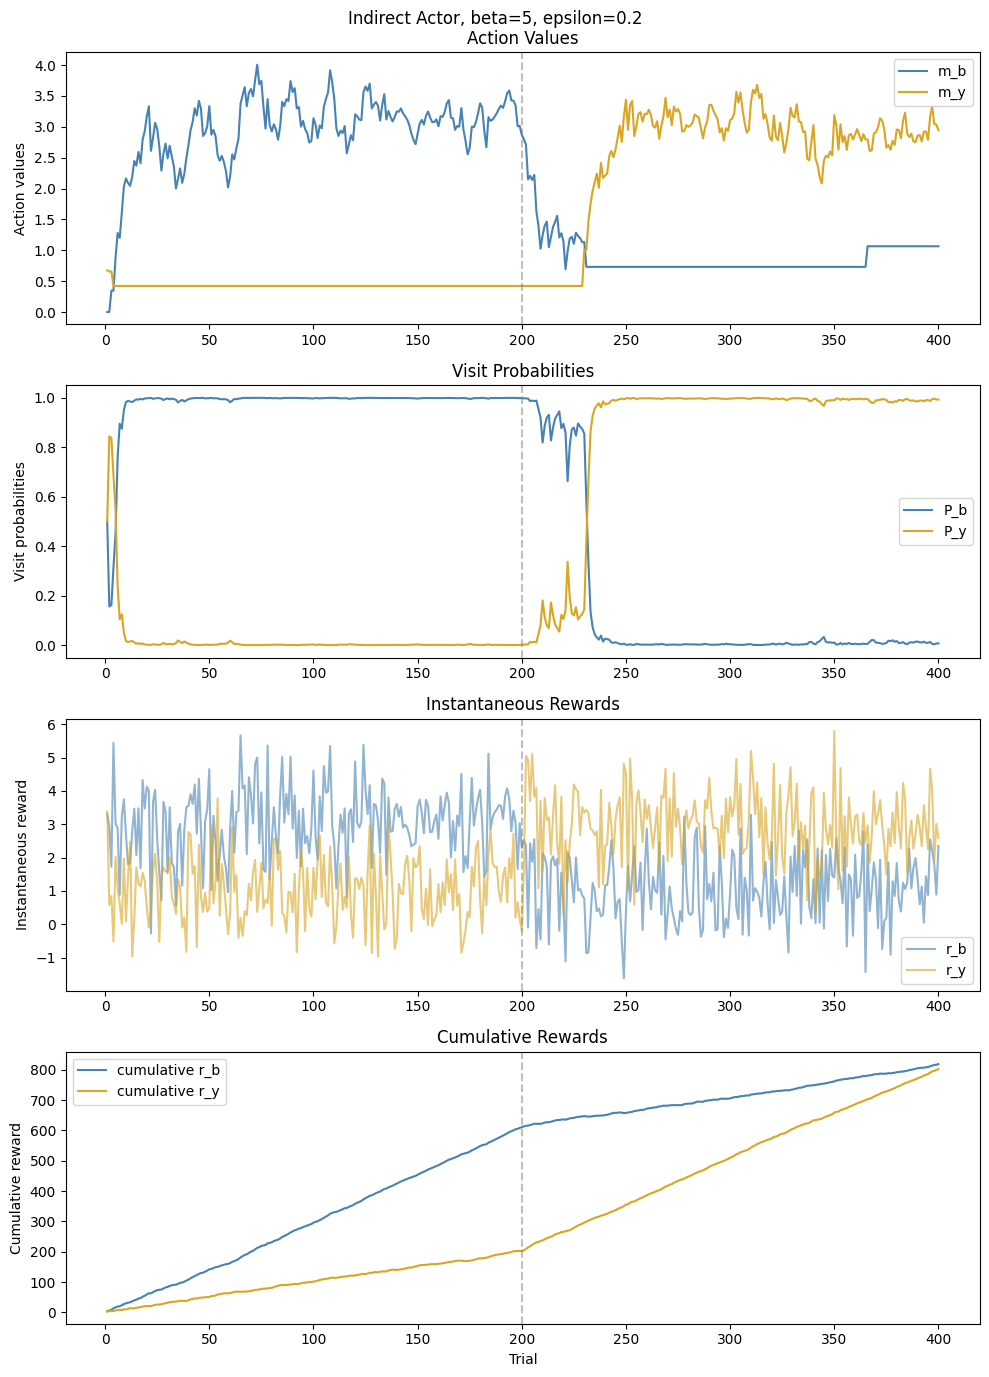

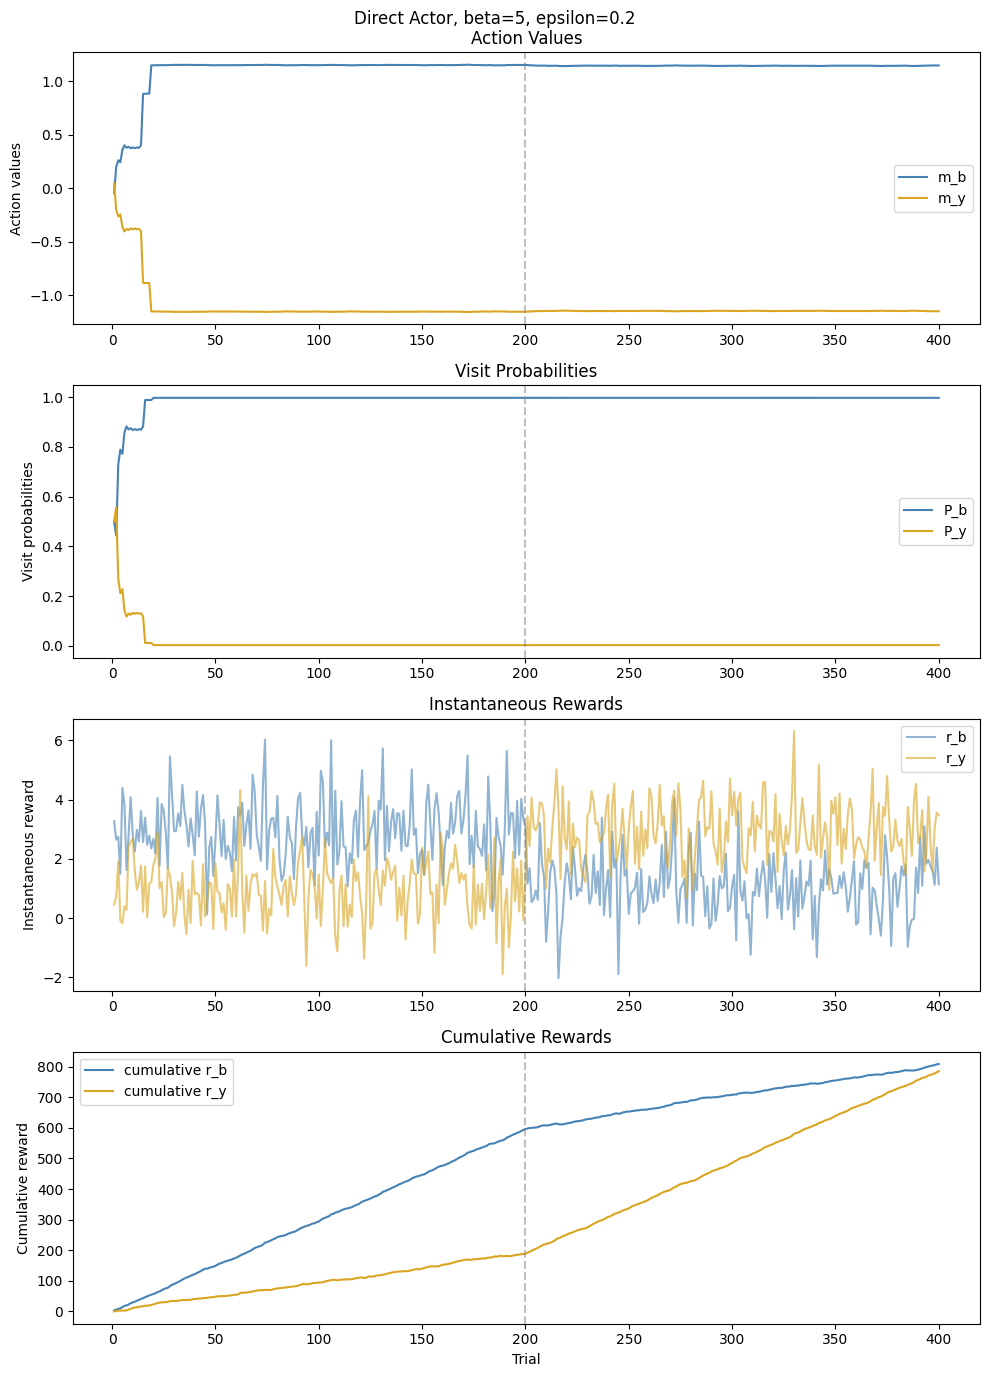

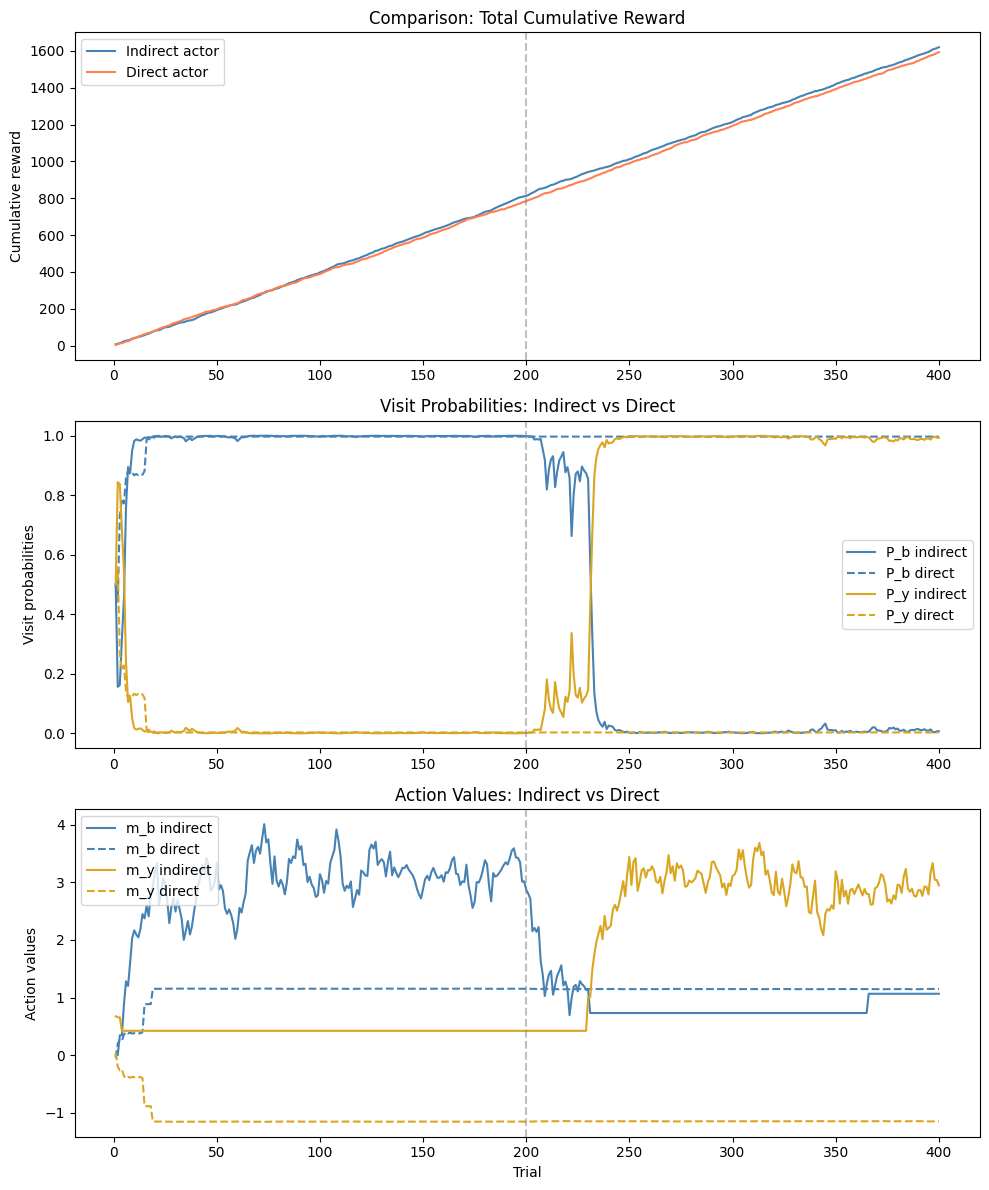

"\nIndirect actor accumulates more total reward\nIndirect actor adapts faster after phase switch\nDirect actor gets stuck, barely shifts after rewards change\nIndirect actor's P_b drops sharply at trial 200, direct actor's barely moves\n\nIndirect actor:\n- m_b (blue) rises to ~3 in phase 1, correctly learning blue gives mean reward 3\n- m_y (yellow) stays near 0 in phase 1, barely visited, barely learned\n- At trial 200 (dashed line), phase switches. m_b drops, m_y rises toward 3\n- P_b goes to nearly 1 in phase 1, then crashes to 0 in phase 2\n- Cumulative reward, steep slope in phase 1 (collecting ~3 per trial), slight flattening right after switch, then recovers\n\nThis is correct behaviour. The indirect actor builds an accurate world model and switches cleanly when rewards change.\n\nDirect Actor:\n- m_b rises in phase 1 but only to ~1, not 3, the direct actor doesn't track absolute reward values, only relative differences\n- m_y goes deeply negative, the direct actor is pushing i

In [1]:
"""
we have two bees - a direct actor bee and an indirect actor bee and two phases, first where it learns to prefer blue in both learning styles
reward is switched and both bees have to update their beliefs

in this regard my code needs to set up parameters such as the learning rate, inverse temperature or exploration-exploitation balance beta,
number of trials and the window size for r_bar in direct actor learning.

furthermore, we use the softmax function that converts action values into probabilities and it uses the exponential function because action values
can be positive or negative but a negative probability is basically meaningless when the task at hand requires you to convert them to a probability.
and we need a function that always outputs positive values, amplifies differences because exponential growth is louder than linear growth, so the better
flower is visited more, and works for any input value
exp() is the only function that meets all of this, ie:
The specific form 1 / (1 + exp(x)) is called the sigmoid function, it basically squashes any number into the range (0, 1), which is required for a probability

So exp() isn't arbitrary, it's an elegant mathematical tool I use to convert unbounded real numbers into valid probabilities.

therefore the softmax function is 1/(1+exp(beta(m_bar-m_b or m_y)))
prediction errors are x2 for indirect actor and x1 for direct actor, because in indirect actor visiting y tells you nothing about visiting b but
in direct actor, the updation rule is based on a running short history estimate of the last 10 trials, therefore, m_b and m_y are changed and their
prediction error is r-r_bar (the average history of the last nwindow of trials from the total)

what this exercise wants me to do and therefore what my code needs to do:

1) set up parameters, beta, epsilon, Ntrials and nwindow of trials for indirect learning
2) initialize mb and my to 0
3) build all containers to shape 2*n
4) run phase one trials 0 to N-1, blue better
5) run phase 2 trials N to 2N-1 (first trial index = 0, last trial index = 2*n-1 and if n is 200, last = 399)

6) each loop must:
for each trial:
  compute m_bar, p_b and p_y by softmax
  mbar = (mb+my)/2
  p_b = 1/(1+exp(beta*(mbar-mb)))
  p_y = 1/(1+exp(beta*(mbar-my)))
  choose flower based on this
  then generate reward from the right distribution so theres instantaneous reward which is what actually arrived random and gaussian that
  fluctuates between trials, expected reward which is the true
  mean actual reward and action value which is current estimate of this reward
  then compute the prediction error
  update the action value mb and my
  store everything in containers

Plot. same zone logic from ex5, visit blue = np.random.rand()<P_b, then use it in reward and the update step.
"""

import numpy as np
import matplotlib.pyplot as plt

# set up parameters
epsilon = 0.2
beta = 5
N = 200

# set weights or action values to 0
m_b = 0.0
m_y = 0.0

# make your containers to store what you would get from the loops, all have 2*N shape
mb_history = np.zeros(2*N)
my_history = np.zeros(2*N)
Pb_history = np.zeros(2*N)
Py_history = np.zeros(2*N)
rb_history = np.zeros(2*N)
ry_history = np.zeros(2*N)
cumrb_history = np.zeros(2*N)
cumry_history = np.zeros(2*N)

cumrb = 0
cumry = 0

# blue is better, phase 1 for both bees
for t in range(N):  # trial in range number of trials, loop for each trial
    # softmax
    # calculate m_bar, P_b and P_y
    m_bar = (m_b + m_y) / 2
    P_b = 1 / (1 + np.exp(beta * (m_bar - m_b)))
    P_y = 1 / (1 + np.exp(beta * (m_bar - m_y)))

    # generate both rewards every trial so we can plot both r_b and r_y regardless of which was visited
    r_b = np.random.normal(3, 1)  # instantaneous actual reward for blue
    r_y = np.random.normal(1, 1)  # instantaneous actual reward for yellow

    # choose flower based on this, so if the random number i generate
    # is lesser than the probability of blue (the zone size) then it gets assigned to this zone, then you calculate
    # prediction error and then update blue, else you make the decision to visit yellow and update yellow
    # np.random.rand generates numbers between 0 and 1

    if np.random.rand() < P_b:
        # visit blue
        delta = r_b - m_b
        m_b = m_b + epsilon * delta
    else:
        # visit yellow
        delta = r_y - m_y
        m_y = m_y + epsilon * delta

    # accumulate cumulative rewards for both flowers regardless of visit
    cumrb += r_b
    cumry += r_y

    # store all this in your containers, update mb history for this trial, my history for this trial, pb history, py history,
    # both rewards, and the cumulative history containers for both flowers
    mb_history[t] = m_b
    my_history[t] = m_y
    Pb_history[t] = P_b
    Py_history[t] = P_y
    rb_history[t] = r_b
    ry_history[t] = r_y
    cumrb_history[t] = cumrb
    cumry_history[t] = cumry

# yellow is better now, phase 2 of indirect responses where rewards are switched up, trials 200 to 399
for t in range(N, 2*N):
    # softmax
    m_bar = (m_b + m_y) / 2
    P_b = 1 / (1 + np.exp(beta * (m_bar - m_b)))
    P_y = 1 / (1 + np.exp(beta * (m_bar - m_y)))

    r_b = np.random.normal(1, 1)
    r_y = np.random.normal(3, 1)

    # choose flower
    if np.random.rand() < P_b:
        # visit blue
        delta = r_b - m_b
        m_b = m_b + epsilon * delta
    else:
        # visit yellow
        delta = r_y - m_y
        m_y = m_y + epsilon * delta

    cumrb += r_b
    cumry += r_y

    # store
    mb_history[t] = m_b
    my_history[t] = m_y
    Pb_history[t] = P_b
    Py_history[t] = P_y
    rb_history[t] = r_b
    ry_history[t] = r_y
    cumrb_history[t] = cumrb
    cumry_history[t] = cumry

# plotting this out
trials = np.arange(1, 2*N + 1)

fig, axes = plt.subplots(4, 1, figsize=(10, 14))
fig.suptitle(f'Indirect Actor, beta={beta}, epsilon={epsilon}')

# action values
axes[0].plot(trials, mb_history, color='steelblue', label='m_b')
axes[0].plot(trials, my_history, color='goldenrod', label='m_y')
axes[0].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Action Values')
axes[0].set_ylabel('Action values')
axes[0].legend()

# visit probabilities
axes[1].plot(trials, Pb_history, color='steelblue', label='P_b')
axes[1].plot(trials, Py_history, color='goldenrod', label='P_y')
axes[1].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Visit Probabilities')
axes[1].set_ylabel('Visit probabilities')
axes[1].legend()

# instantaneous rewards, both b and y
axes[2].plot(trials, rb_history, color='steelblue', alpha=0.6, label='r_b')
axes[2].plot(trials, ry_history, color='goldenrod', alpha=0.6, label='r_y')
axes[2].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Instantaneous Rewards')
axes[2].set_ylabel('Instantaneous reward')
axes[2].legend()

# cumulative rewards, both b and y
axes[3].plot(trials, cumrb_history, color='steelblue', label='cumulative r_b')
axes[3].plot(trials, cumry_history, color='goldenrod', label='cumulative r_y')
axes[3].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[3].set_title('Cumulative Rewards')
axes[3].set_ylabel('Cumulative reward')
axes[3].set_xlabel('Trial')
axes[3].legend()

plt.tight_layout()
plt.show()


# Task 2: Direct Actor

m_b = 0.0  # set weights
m_y = 0.0

mb_history_d = np.zeros(2*N)
my_history_d = np.zeros(2*N)
Pb_history_d = np.zeros(2*N)
Py_history_d = np.zeros(2*N)
rb_history_d = np.zeros(2*N)
ry_history_d = np.zeros(2*N)
cumrb_history_d = np.zeros(2*N)
cumry_history_d = np.zeros(2*N)
r_window = []  # last 10 rewards, window container

cumrb = 0
cumry = 0

# Phase 1, blue better
for t in range(N):
    m_bar = (m_b + m_y) / 2
    P_b = 1 / (1 + np.exp(beta * (m_bar - m_b)))
    P_y = 1 / (1 + np.exp(beta * (m_bar - m_y)))

    # r_bar = the mean of r_window responses, if the length of r_window is greater than 0, else 0.0
    r_bar = np.mean(r_window) if len(r_window) > 0 else 0.0

    r_b = np.random.normal(3, 1)
    r_y = np.random.normal(1, 1)

    if np.random.rand() < P_b:
        delta = r_b - r_bar
        m_b = m_b + epsilon * (1 - P_b) * delta  # larger update if blue was visited less, smaller update if bee visits blue a lot
        m_y = m_y - epsilon * P_y * delta  # P_y is the room for y to shrink
        r_window.append(r_b)
    else:
        delta = r_y - r_bar
        m_b = m_b - epsilon * P_b * delta
        m_y = m_y + epsilon * (1 - P_y) * delta
        r_window.append(r_y)

    # Add new reward to the window.
    # If window has more than 10 entries, remove the oldest one. This keeps r_bar as a running average of the last 10 trials only
    if len(r_window) > 10:
        r_window.pop(0)  # not a tuple, a list, so it removes the oldest entry once we cross the ten trial mark

    cumrb += r_b
    cumry += r_y

    mb_history_d[t] = m_b
    my_history_d[t] = m_y
    Pb_history_d[t] = P_b
    Py_history_d[t] = P_y
    rb_history_d[t] = r_b
    ry_history_d[t] = r_y
    cumrb_history_d[t] = cumrb
    cumry_history_d[t] = cumry

# Phase 2, direct actor, yellow better
for t in range(N, 2*N):
    m_bar = (m_b + m_y) / 2
    P_b = 1 / (1 + np.exp(beta * (m_bar - m_b)))
    P_y = 1 / (1 + np.exp(beta * (m_bar - m_y)))

    r_bar = np.mean(r_window) if len(r_window) > 0 else 0.0

    r_b = np.random.normal(1, 1)
    r_y = np.random.normal(3, 1)

    if np.random.rand() < P_b:
        delta = r_b - r_bar
        m_b = m_b + epsilon * (1 - P_b) * delta
        m_y = m_y - epsilon * P_y * delta
        r_window.append(r_b)
    else:
        delta = r_y - r_bar
        m_b = m_b - epsilon * P_b * delta
        m_y = m_y + epsilon * (1 - P_y) * delta
        r_window.append(r_y)

    if len(r_window) > 10:
        r_window.pop(0)

    cumrb += r_b
    cumry += r_y

    mb_history_d[t] = m_b
    my_history_d[t] = m_y
    Pb_history_d[t] = P_b
    Py_history_d[t] = P_y
    rb_history_d[t] = r_b
    ry_history_d[t] = r_y
    cumrb_history_d[t] = cumrb
    cumry_history_d[t] = cumry

# Task 2 Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 14))
fig.suptitle(f'Direct Actor, beta={beta}, epsilon={epsilon}')

axes[0].plot(trials, mb_history_d, color='steelblue', label='m_b')
axes[0].plot(trials, my_history_d, color='goldenrod', label='m_y')
axes[0].axvline(x=N, color='gray', linestyle='--', alpha=0.5)  # denotes where exactly reward switched
axes[0].set_title('Action Values')
axes[0].set_ylabel('Action values')
axes[0].legend()

axes[1].plot(trials, Pb_history_d, color='steelblue', label='P_b')
axes[1].plot(trials, Py_history_d, color='goldenrod', label='P_y')
axes[1].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Visit Probabilities')
axes[1].set_ylabel('Visit probabilities')
axes[1].legend()

axes[2].plot(trials, rb_history_d, color='steelblue', alpha=0.6, label='r_b')
axes[2].plot(trials, ry_history_d, color='goldenrod', alpha=0.6, label='r_y')
axes[2].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Instantaneous Rewards')
axes[2].set_ylabel('Instantaneous reward')
axes[2].legend()

axes[3].plot(trials, cumrb_history_d, color='steelblue', label='cumulative r_b')
axes[3].plot(trials, cumry_history_d, color='goldenrod', label='cumulative r_y')
axes[3].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[3].set_title('Cumulative Rewards')
axes[3].set_ylabel('Cumulative reward')
axes[3].set_xlabel('Trial')
axes[3].legend()

plt.tight_layout()
plt.show()


# Task 3: Comparison
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# compare cumulative reward totals (sum of both flowers) for indirect vs direct
total_cum_indirect = cumrb_history + cumry_history
total_cum_direct = cumrb_history_d + cumry_history_d

axes[0].plot(trials, total_cum_indirect, color='steelblue', label='Indirect actor')
axes[0].plot(trials, total_cum_direct, color='coral', label='Direct actor')
axes[0].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Comparison: Total Cumulative Reward')
axes[0].set_ylabel('Cumulative reward')
axes[0].legend()

# compare visit probabilities for blue
axes[1].plot(trials, Pb_history, color='steelblue', linestyle='-', label='P_b indirect')
axes[1].plot(trials, Pb_history_d, color='steelblue', linestyle='--', label='P_b direct')
axes[1].plot(trials, Py_history, color='goldenrod', linestyle='-', label='P_y indirect')
axes[1].plot(trials, Py_history_d, color='goldenrod', linestyle='--', label='P_y direct')
axes[1].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Visit Probabilities: Indirect vs Direct')
axes[1].set_ylabel('Visit probabilities')
axes[1].legend()

# compare action values
axes[2].plot(trials, mb_history, color='steelblue', linestyle='-', label='m_b indirect')
axes[2].plot(trials, mb_history_d, color='steelblue', linestyle='--', label='m_b direct')
axes[2].plot(trials, my_history, color='goldenrod', linestyle='-', label='m_y indirect')
axes[2].plot(trials, my_history_d, color='goldenrod', linestyle='--', label='m_y direct')
axes[2].axvline(x=N, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Action Values: Indirect vs Direct')
axes[2].set_ylabel('Action values')
axes[2].set_xlabel('Trial')
axes[2].legend()

plt.tight_layout()
plt.show()


"""
Indirect actor accumulates more total reward
Indirect actor adapts faster after phase switch
Direct actor gets stuck, barely shifts after rewards change
Indirect actor's P_b drops sharply at trial 200, direct actor's barely moves

Indirect actor:
- m_b (blue) rises to ~3 in phase 1, correctly learning blue gives mean reward 3
- m_y (yellow) stays near 0 in phase 1, barely visited, barely learned
- At trial 200 (dashed line), phase switches. m_b drops, m_y rises toward 3
- P_b goes to nearly 1 in phase 1, then crashes to 0 in phase 2
- Cumulative reward, steep slope in phase 1 (collecting ~3 per trial), slight flattening right after switch, then recovers

This is correct behaviour. The indirect actor builds an accurate world model and switches cleanly when rewards change.

Direct Actor:
- m_b rises in phase 1 but only to ~1, not 3, the direct actor doesn't track absolute reward values, only relative differences
- m_y goes deeply negative, the direct actor is pushing it down to create contrast with blue
- P_b still reaches 1 correctly
- After phase switch, barely adapts. P_b stays near 1 even in phase 2 when yellow is better. m_y stays negative and barely recovers
- Cumulative reward, much flatter slope, much lower total

This shows the direct actor's weakness: it exploits well once it has a preference, but adapts very slowly when the world changes.

Comparison:
- Indirect actor accumulates more total reward overall
- In phase 1 they're similar, both learn blue is better
- After the switch, indirect actor adapts within roughly 30 trials. Direct actor barely adapts at all in 200 trials

The visit probabilities confirm this: indirect actor's P_b drops sharply after trial 200 and P_y rises. Direct actor's P_b stays near 1, it's stuck.

Therefore:

The indirect actor is better because it maintains an accurate model of each flower's reward. When the world changes, it can update that model and shift behaviour quickly.

The direct actor only tracks relative preferences, ie it doesn't know the absolute value of each flower. So when rewards switch, it has no mechanism to rapidly unlearn its old preference.
"""